# Глубинное обучение 1 / Введение в глубинное обучение, ФКН ВШЭ

## Домашнее задание 3: RNN и языковые модели 

### Общая информация

Оценка после штрафа после мягкого дедлайна вычисляется по формуле $M_{\text{penalty}} = M_{\text{full}} \cdot 0.85^{t/1440}$, где $M_{\text{full}}$ — полная оценка за работу без учета штрафа, а $t$ — время в минутах, прошедшее после мягкого дедлайна (округление до двух цифр после запятой). Таким образом, спустя первые сутки после мягкого дедлайна вы не можете получить оценку выше 12.75, а если сдать через четыре дня после мягкого дедлайна, то ваш максимум — 7.83 балла.

### Оценивание и штрафы

Максимально допустимая оценка за работу — 15 баллов. Сдавать задание после указанного срока сдачи нельзя.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов. Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке. Также оценка может быть снижена за плохо читаемый код и плохо оформленные графики. Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

### О задании

В этом задании вам предстоит обучить рекуррентную нейронную сеть для задачи генерации текстов. В качестве данных возьмем набор из 120 тысяч анекдотов (всех категорий от А до Я включительно). Его вы можете найти в архиве `jokes.txt.zip`, который доступен по [ссылке](https://disk.yandex.com/d/fjt5xICH-ukEEA).

In [1]:
%load_ext autoreload
%autoreload 2

## Задание 1: Dataset (1 балл)

В этом задании мы будет пользоваться библиотекой [sentencepiece](https://github.com/google/sentencepiece), которая поддерживает разные форматы токенизации текстов, в том числе BPE, который мы и будем использовать. Реализуйте недостающие фрагменты кода в классе `TextDataset` в файле `dataset.py`. Датасет обучает sentencepiece токенизатор, токенизирует тексты, превращает токены в индексы и паддит до одной и той же длины (параметр `max_length`). Не забудьте, что для генерации текстов нам будут нужны специальные токены начала и конца последовательности, соответственно `BOS` и `EOS`. Существуют еще два специальных токена &mdash; паддинг `PAD` и токен `UNK`, заменяющий out-of-vocabulary токены.

In [2]:
#!pip install sentencepiece

In [3]:
import torch
import numpy as np
from dataset import TextDataset

In [4]:
train_set = TextDataset(data_file='jokes.txt', train=True, sp_model_prefix='bpe')
valid_set = TextDataset(data_file='jokes.txt', train=False, sp_model_prefix='bpe')

In [5]:
# Код должен проходить тесты
assert len(train_set) + len(valid_set) == 120759

for _ in range(5):
    for dataset in (train_set, valid_set):
        indices, length = dataset[np.random.randint(len(dataset))]
        assert indices.shape == (dataset.max_length, )
        assert indices[0].item() == dataset.bos_id
        assert (indices == dataset.eos_id).sum().item() == 1

        eos_pos = indices.tolist().index(dataset.eos_id)
        assert torch.all(indices[eos_pos + 1:] == dataset.pad_id)
        assert (indices != dataset.pad_id).sum() == length

## Задание 2 Language model (3.5 балла)

Реализуйте класс `LanguageModel` из файла `model.py`. Мы будем генерировать текст с помощью языковой модели &mdash; это авторегрессионная вероятностная модель, которая предсказывает распределение следующего токена при условии предыдущих:

$$
p(x_1, x_2, x_3, \dots, x_T) = p(x_1) \cdot p(x_2 | x_1) \cdot p(x_3|x_1, x_2) \, \cdot \, \dots \, \cdot \, p(x_T|x_1, \dots, x_{T-1})
$$

Мы будем реализовывать ее с помощью рекуррентной нейронной сети. Ваш код должен поддерживать возможность работать как с оригинальной [RNN](https://pytorch.org/docs/stable/generated/torch.nn.RNN.html#torch.nn.RNN), так и c [LSTM](https://bitly.com/98K8eH). На каждом временном шаге модель возвращает логиты вероятностей для следующего токена. Модель будет работать в двух режимах (не путать с `.train()` и `.eval()`):

- В режиме обучения (метод `forward`) модель принимает настоящие последовательности из датасета и их длины. На каждом временном шаге возвращаются логиты вероятностей следующего токена, что позволяет считать лосс, обучаться на трейне и валидироваться на валидации.

- В режиме генерации (инференса, метод `inference`) модель принимает некоторый префикс (возможно пустой), с которого начинать генерацию, и продолжает его. Для этого на каждом шаге генерируются новые логиты, семплируется новый токен (из распределения, заданного логитами), и процесс продолжается, пока не будет сгенерирован токен `EOS` или не будет достигнуто ограничение на длину последовательности. **Обратите внимание**, что вам не нужно прогонять всю последовательность заново через RNN после каждого нового токена, это приведет к квадратичной сложности по длине последовательности. Вам достаточно обновлять скрытое состояние, подавая на вход новый сгенерированный токен и предыдущее скрытое состояние. Кроме того, чтобы получить больше контроля над генерацией, вводится параметр температуры `temp`. Перед семплированием нужно разделить на него логиты, полученные моделью. 

In [6]:
from model import LanguageModel

In [7]:
model = LanguageModel(train_set)

In [8]:
# Код должен проходить тесты
for bs in [1, 4, 16, 64, 256]:
    indices = torch.randint(high=train_set.vocab_size, size=(bs, train_set.max_length))
    lengths = torch.randint(low=1, high=train_set.max_length + 1, size=(bs, ))
    logits = model(indices, lengths)
    assert logits.shape == (bs, lengths.max(), train_set.vocab_size)

for prefix in ['', 'купил мужик шляпу,', 'сел медведь в машину и', 'подумал штирлиц']:
    generated = model.inference(prefix, temp=np.random.uniform(0.1, 10))
    assert type(generated) == str
    assert generated.startswith(prefix)

## Задание 3: Training (2 балла)

Всё, что нам осталось &mdash; реализовать цикл обучения. Заполните пропуски в файле `train.py`. Не забудьте, что мы учим модель предсказывать вероятность следующего, а не текущего токена. Также рекомендуется обрезать батч индексов по самой длинной последовательности, чтобы не гонять паддинги вхолостую. Для оценки качества генерации будем использовать метрику [perplexity](https://towardsdatascience.com/perplexity-in-language-models-87a196019a94). Реализуйте ее подсчет в функции `plot_losses` (да, для этого достаточно только значения лосса).

Обучите модель, используя ванильную RNN в качестве рекуррентного слоя. Сохраните чекпойнт обученной модели, он нам еще пригодится. 

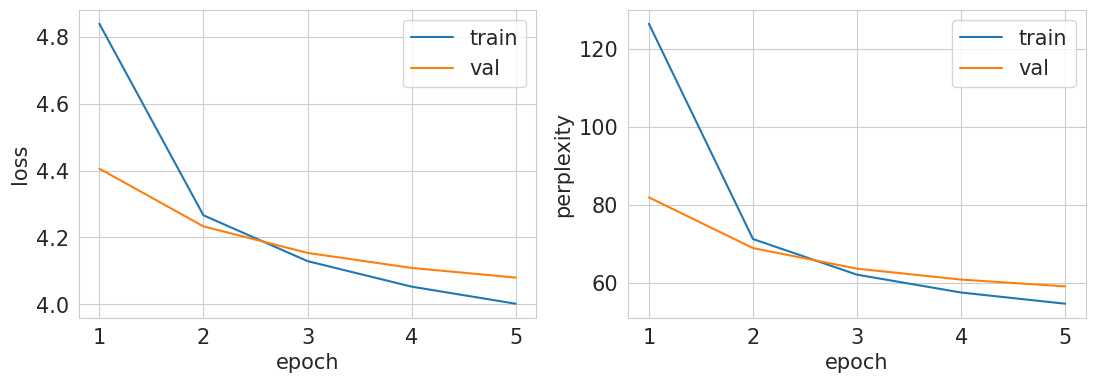

Generation examples:
- у тебя в барешник обувинки, кто- твоей тоже то сам, пожарной!
двое мира. уход от плохих сильно холостяков. пошел увидел в чем у тебя есть.
в лес в россии властила незаметного реагов, обижающего без патологоанатом. и вот и то, что они ним. и не задолженным взглядом боя.
не успешности у которых утезолей?!- а зачем вы?- вы что, котенка дерксилась.
в квартире, которые вроде другого языка магню-шопостом, весь день не хочет пропить демократи!- извиня - козель!- из дома.


In [9]:
from train import train

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_rnn = LanguageModel(train_set, rnn_type=torch.nn.RNN).to(device)
optimizer = torch.optim.Adam(model_rnn.parameters(), lr=1e-3)

train_loader = torch.utils.data.DataLoader(train_set, batch_size=64, shuffle=True)
valid_loader = torch.utils.data.DataLoader(valid_set, batch_size=64, shuffle=False)

train(model_rnn, optimizer, None, train_loader, valid_loader, num_epochs=5)
torch.save(model_rnn.state_dict(), 'rnn_checkpoint.pt')

## Задание 4: LSTM (0.5 балла)

Обучите аналогичную модель, но с LSTM в качестве рекуррентного слоя. Сравните модели по метрикам и генерации. Не забывайте про чекпойнты!

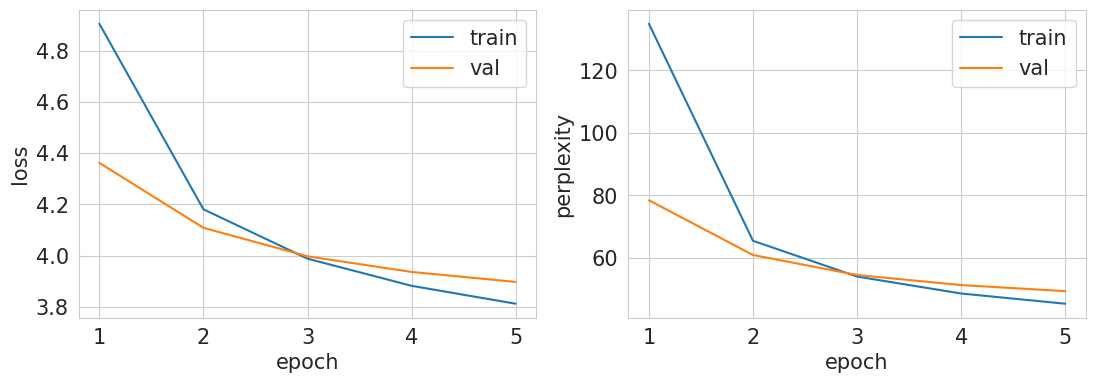

Generation examples:
раалисту в декрет, отличи отсели нового, блондинки реждерва бедня - мукатиин ускъявил пенсии синем и отзначут жителей. актив.
налог хокке пережит последние 100 лет, переписию пользуя своего пукающий шоколадки и перегарается ли буратино спорака - 2 старенький-летнийок.
- дорогая, это мужчина с морозам!- да.- модель, три мадам, который сует! вы отпустиваем?- нет, конечно еще помню подровь, но вроде могут...
разговаривают два русском радистку и говорит- да есть, руль вернулся, пожалуйста, скачаются рубись!
в свет арбубе в поискольпах вращается. говорит странице прохлый, раде оргазется- кто там?- руварит, тогда вы и знали!- помогите! - сказал один бор слишком классный туалет, что в 25 надо что-то задавать лучше, чре ей будет пришчить. мойша, мы же с открытым мяг, и я вообще не гуляет.а думает уже домой, она отпустить, принимать потом папутоза.


In [10]:
model_lstm = LanguageModel(train_set, rnn_type=torch.nn.LSTM).to(device)
optimizer = torch.optim.Adam(model_lstm.parameters(), lr=1e-3)

train(model_lstm, optimizer, None, train_loader, valid_loader, num_epochs=5)
torch.save(model_lstm.state_dict(), 'lstm_checkpoint.pt')

**Мои комментарии:** LSTM чуть лучше и по loss'у, и по perplexity

## Задание 5: Sampling temperature (0.5 балла)

Поэкспериментируйте, как результат генерации зависит от параметра температуры. Попробуйте генерацию с разными префиксами. Сделайте выводы. 

In [11]:
prefixes = ['купил мужик шляпу,', 'сел медведь в машину и', 'штирлиц заходит в бар,']
temperatures = [0.1, 0.5, 1.0, 2.0, 5.0]

for prefix in prefixes:
    print(f'--- Prefix: "{prefix}" ---')
    for temp in temperatures:
        generated = model_lstm.inference(prefix, temp=temp)
        print(f'  Temp {temp:.1f}: {generated}')
    print()

--- Prefix: "купил мужик шляпу," ---
  Temp 0.1: купил мужик шляпу, а у меня в каком-то яхте, а я - в этом году.
  Temp 0.5: купил мужик шляпу, сэр.
  Temp 1.0: купил мужик шляпу, а другой - по жалуется- вы не хотите, то это к чиновнику?- ну. почему?- бог у них сразу приходится.
  Temp 2.0: купил мужик шляпу, при своей мини двое зубо закрыться туалет свивавые подо другчице к вранья у другой почта полнещее нужностей мои странно было работает ли подумать в накольные следующих солнца народ!- кланьуч может бышут тогда очнулся? наверное государство по воктере самое сне свободное беут свород рублей они признаков освежитетно там написали хлебе вчера руки конелен языч кондуктовый поро ювачные прыгает надуск!- зачем уталуевой гера как б онла замет
  Temp 5.0: купил мужик шляпу, ма подълоги лодела есть ты ночью немного усы хочетри эти встречаких хоте спрастивори деньнибудь единствен оказа пять автобудцанок пожа этой пере пришел требу второй увился изрова. тут отпу зако восчитьет.- одновра дей об

**Мой вывод:** с бОльшей температурой приходит большая "экспрессия" и менее надёжны генерации ставносятся. Где-то обрезаются слова, где-то даже на цифры заменяются буквы и тп.

## Задание 5: Tokenizers (1 балл)

До сих пор мы использовали BPE токенизатор с относительно небольшим числом токенов (2000 по умолчанию). Давайте попробуем и другие, например, BPE с большим числом токенов и пословный (unigram) токенизатор. Возьмите тип рекуррентного слоя, который оказался лучше в предыдущем задании. Обучите модели на таких токенизаторах и сравните их генерацию. Не забывайте сохранять чекпойнты. Правильно ли сравнивать между собой получившиеся модели по значению perplexity? Почему?

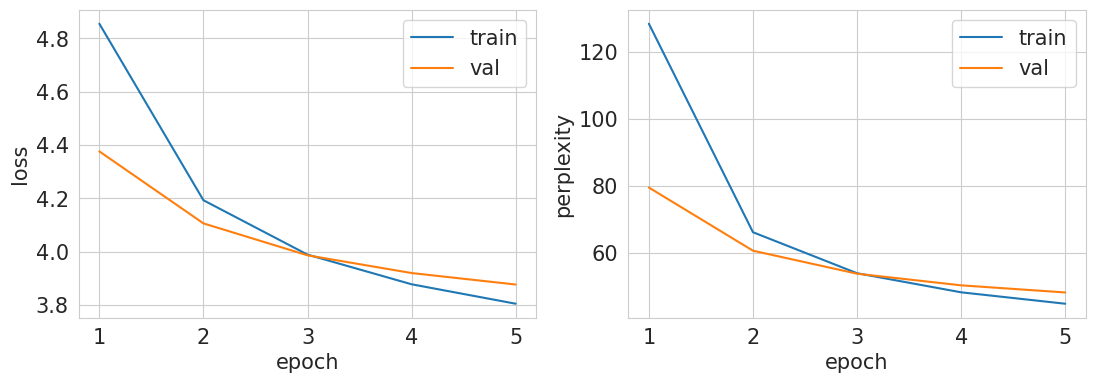

Generation examples:
зашел чай на затолоном пьбл. заборенные известные гелендающихологии запретили ному, пока совершает такого возраста.
многие обещания - отказавшись, володное заблокированные ищов.
итали последняя бутербродов власть булков- ну, дорогой! мы домой, слышишь на работу.- мой мир простить дорогая?- а как ты к становла?- а нашемусяк. но из уточки и проснется.
- папа, а можно я заплатуть - сколько я на работу берем?- любимый магазин.проктновый конечно видела намекана от белого руба. про такого числа!
фабрижена, распленные поменам плекольно на кота отреаприятии, оборотался штирлиц к маленькую в 1 ⁇  промышений бугобизмом. теперь у меня есть бантыльных и пьегят.


In [12]:
print("Training BPE with vocab_size=5000...")
train_set_bpe_large = TextDataset(data_file='jokes.txt', train=True, sp_model_prefix='bpe_large', vocab_size=5000)
valid_set_bpe_large = TextDataset(data_file='jokes.txt', train=False, sp_model_prefix='bpe_large', vocab_size=5000)

model_bpe_large = LanguageModel(train_set_bpe_large, rnn_type=torch.nn.LSTM).to(device)
optimizer_bpe_large = torch.optim.Adam(model_bpe_large.parameters(), lr=1e-3)

train_loader_bpe_large = torch.utils.data.DataLoader(train_set_bpe_large, batch_size=64, shuffle=True)
valid_loader_bpe_large = torch.utils.data.DataLoader(valid_set_bpe_large, batch_size=64, shuffle=False)

train(model_bpe_large, optimizer_bpe_large, None, train_loader_bpe_large, valid_loader_bpe_large, num_epochs=5)
torch.save(model_bpe_large.state_dict(), 'lstm_bpe_large.pt')

print("\nTraining Unigram tokenizer...")
train_set_unigram = TextDataset(data_file='jokes.txt', train=True, sp_model_prefix='unigram', model_type='unigram', vocab_size=2000)
valid_set_unigram = TextDataset(data_file='jokes.txt', train=False, sp_model_prefix='unigram', model_type='unigram', vocab_size=2000)

model_unigram = LanguageModel(train_set_unigram, rnn_type=torch.nn.LSTM).to(device)
optimizer_unigram = torch.optim.Adam(model_unigram.parameters(), lr=1e-3)

train_loader_unigram = torch.utils.data.DataLoader(train_set_unigram, batch_size=64, shuffle=True)
valid_loader_unigram = torch.utils.data.DataLoader(valid_set_unigram, batch_size=64, shuffle=False)

train(model_unigram, optimizer_unigram, None, train_loader_unigram, valid_loader_unigram, num_epochs=5)
torch.save(model_unigram.state_dict(), 'lstm_unigram.pt')

**Мои комментарии**: нельзя их сравнивать по perplexity, тк perplexity зависит от размера и состава словаря токенизатора и, таким образом, мы не ставим в одни условия для проведения сравнений

## Задание 6. Latent Semantic Analysis (2 балла)

Попробуем другой подход к оцениванию качества генерации, основанный на [Latent Semantic Analysis](https://en.wikipedia.org/wiki/Latent_semantic_analysis). Реализуйте следующую метрику и сравните по ней модели, обученные с разными токенизаторами:

1. Генерируем обученной моделью выборку текстов, совпадающую по размеру с валидационной выборкой.
2. Объединяем две выборки текстов (валидационную и сгенерированную) в один корпус. Обратите внимание, что наша токенизация в общем случае необратима, поэтому для чистоты эксперимента нужно закодировать и декодировать валидационную выборку.
3. Генерируем tf-idf матрицу для полученного корпуса.
4. Понижаем размерность матрицы с помощью [SVD](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html).
5. Теперь у нас есть векторы, описывающие валидационные и сгенерированные тексты, лежащие в одном пространстве. Для каждого вектора, отвечающего сгенерированному тексту, найдем наибольший cosine similarity между ним и вектором валидационного текста. Усредним такие similarity по всем сгенерированным текстам и получим число, характеризующее похожесть сгенерированной выборки на валидационную.

Какие плюсы и минусы есть у описанной метрики?

In [13]:
import pandas as pd
from tqdm import tqdm
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity

LSA_RANDOM_STATE = 42
LSA_N_COMPONENTS = 100

In [14]:
def decode_validation_texts(dataset):
    encoded = dataset.sp_model.encode(dataset.texts)
    decoded = dataset.sp_model.decode(encoded)
    return decoded

def generate_texts(model, n_samples, prefix='', temp=1.0):
    generated = []
    for _ in tqdm(range(n_samples), desc=f"Generating {n_samples} samples"):
        generated.append(model.inference(prefix=prefix, temp=temp))
    return generated

In [15]:
def build_lsa_embeddings(valid_texts, gen_texts, n_components=LSA_N_COMPONENTS, random_state=LSA_RANDOM_STATE):
    all_texts = valid_texts + gen_texts
    
    vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=10000)
    tfidf_matrix = vectorizer.fit_transform(all_texts)
    
    svd = TruncatedSVD(n_components=n_components, random_state=random_state)
    lsa_matrix = svd.fit_transform(tfidf_matrix)
    
    valid_vecs = lsa_matrix[:len(valid_texts)]
    gen_vecs = lsa_matrix[len(valid_texts):]
    
    return valid_vecs, gen_vecs

def lsa_similarity_score(valid_vecs, gen_vecs):
    sim_matrix = cosine_similarity(gen_vecs, valid_vecs)
    max_sims = sim_matrix.max(axis=1)
    return max_sims.mean()

In [16]:
def evaluate_model_lsa(model, dataset, n_samples=None):
    if n_samples is None:
        n_samples = len(dataset)
        
    valid_texts = decode_validation_texts(dataset)
    gen_texts = generate_texts(model, n_samples=n_samples)
    
    valid_vecs, gen_vecs = build_lsa_embeddings(valid_texts, gen_texts)
    score = lsa_similarity_score(valid_vecs, gen_vecs)
    
    return {
        'score': score,
        'valid_vecs': valid_vecs,
        'gen_vecs': gen_vecs
    }

In [17]:
models_to_evaluate = [
    ('LSTM_BPE_2000', model_lstm, valid_set),
    ('LSTM_BPE_5000', model_bpe_large, valid_set_bpe_large),
    ('LSTM_Unigram_2000', model_unigram, valid_set_unigram)
]

lsa_results = []
lsa_artifacts = {} # For Task 7

for name, model, dataset in models_to_evaluate:
    print(f"Evaluating {name}...")
    res = evaluate_model_lsa(model, dataset, n_samples=len(dataset))
    lsa_results.append({'Model': name, 'LSA_Similarity': res['score']})
    lsa_artifacts[name] = res

df_res = pd.DataFrame(lsa_results).sort_values('LSA_Similarity', ascending=False)
df_res

Evaluating LSTM_BPE_2000...


Generating 6037 samples: 100%|██████████| 6037/6037 [01:37<00:00, 61.80it/s]


Evaluating LSTM_BPE_5000...


Generating 6037 samples: 100%|██████████| 6037/6037 [01:25<00:00, 70.55it/s]


Evaluating LSTM_Unigram_2000...


Generating 6037 samples: 100%|██████████| 6037/6037 [02:03<00:00, 48.93it/s]


,Model,LSA_Similarity
2,LSTM_Unigram_2000,0.733480
1,LSTM_BPE_5000,0.732884
0,LSTM_BPE_2000,0.729469


**Мои комментарии**:
 
**Плюсы:** метрика быстро проверяет, насколько сгенерированные тексты похожи на реальные по “темам и словам”: мы переводим оба корпуса в одно пространство и смотрим близость, при этом редкие и более информативные слова учитываются сильнее, чем частые


**Минусы:** она скорее меряет совпадение по словарю, чем качество смысла и связности, поэтому текст может быть “похожим” по ключевым словам, но плохим по грамматике/логике. Кщё оценка зависит от настроек TF‑IDF/SVD и длины текстов, а выбор максимальной похожести на один вал-текст может завышать результат и не штрафует за однообразие (много похожих генераций).

## Задание 7. Visualization (1 балл)

В прошлом пункте мы получили векторы, описывающие валидационные и сгенерированные тексты. Попробуем визуализировать их. Примените [TSNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html) к этим векторам и нарисуйте scatter-plot с получившимися двумерными представлениями. Точки, соответствующие валидационным и сгенерированным текстам, должны быть разного цвета. Визуализируйте таким образом все три модели для разных токенизаторов. 

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

TSNE_CFG = {
    'random_state': 42,
    'perplexity': 30,
    'n_iter': 1000,
    'max_points_per_class': 1500
}

In [19]:
def prepare_tsne_input(valid_vecs, gen_vecs, max_points_per_class=None, random_state=42):
    np.random.seed(random_state)
    
    if max_points_per_class:
        v_idx = np.random.choice(len(valid_vecs), min(len(valid_vecs), max_points_per_class), replace=False)
        g_idx = np.random.choice(len(gen_vecs), min(len(gen_vecs), max_points_per_class), replace=False)
        v_sampled = valid_vecs[v_idx]
        g_sampled = gen_vecs[g_idx]
    else:
        v_sampled, g_sampled = valid_vecs, gen_vecs
        
    X = np.vstack([v_sampled, g_sampled])
    labels = ['valid'] * len(v_sampled) + ['generated'] * len(g_sampled)
    return X, labels

def make_tsne_projection(X, cfg):
    perp = min(cfg['perplexity'], len(X) - 1)
    tsne = TSNE(
        n_components=2, 
        perplexity=perp, 
        random_state=cfg['random_state'], 
        max_iter=cfg['n_iter'],
        init='pca', 
        learning_rate='auto'
    )
    return tsne.fit_transform(X)

In [20]:
def plot_tsne_projection(X_2d, labels, title):
    plt.figure(figsize=(10, 7))
    sns.scatterplot(
        x=X_2d[:, 0], 
        y=X_2d[:, 1], 
        hue=labels, 
        palette={'valid': 'blue', 'generated': 'orange'},
        alpha=0.5,
        s=20
    )
    plt.title(title)
    plt.xlabel("t-SNE dim 1")
    plt.ylabel("t-SNE dim 2")
    plt.legend(title="Source")
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.show()

In [21]:
def visualize_model_tsne(model_name, artifact, cfg):
    print(f"Processing t-SNE for {model_name}...")
    
    X, labels = prepare_tsne_input(
        artifact['valid_vecs'], 
        artifact['gen_vecs'], 
        max_points_per_class=cfg['max_points_per_class'],
        random_state=cfg['random_state']
    )
    
    X_2d = make_tsne_projection(X, cfg)
    
    plot_tsne_projection(X_2d, labels, f"t-SNE Visualization: {model_name}")
    
    return X_2d, labels

Processing t-SNE for LSTM_BPE_2000...


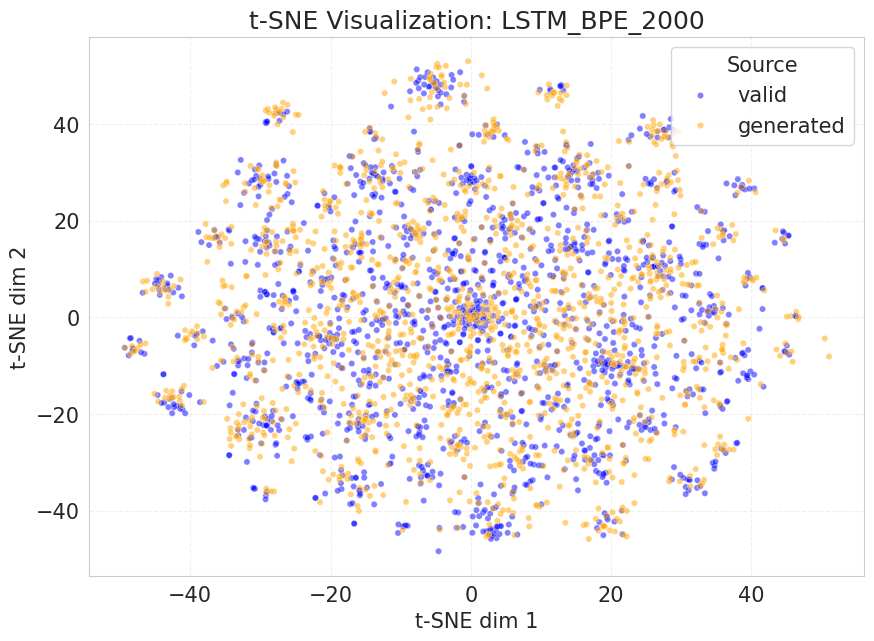

Processing t-SNE for LSTM_BPE_5000...


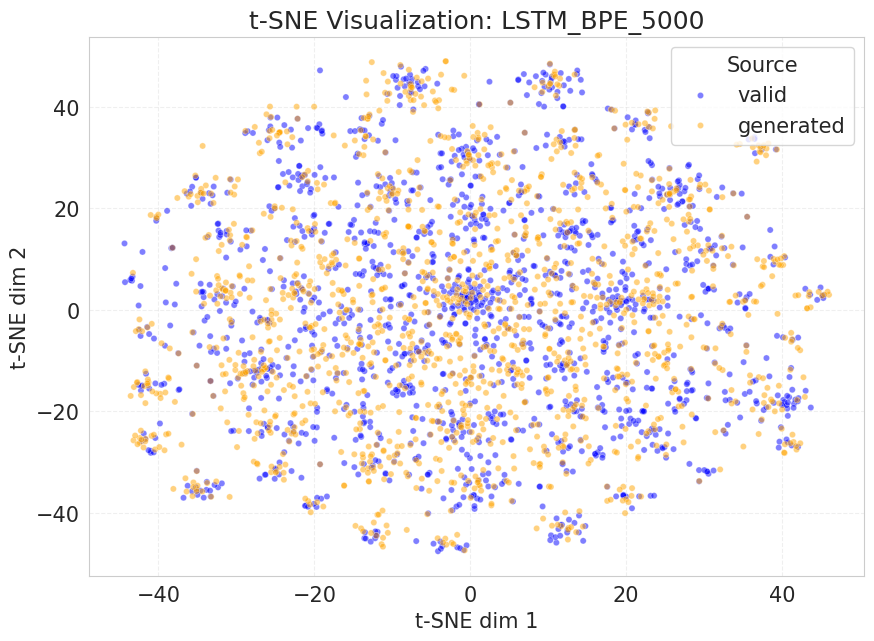

Processing t-SNE for LSTM_Unigram_2000...


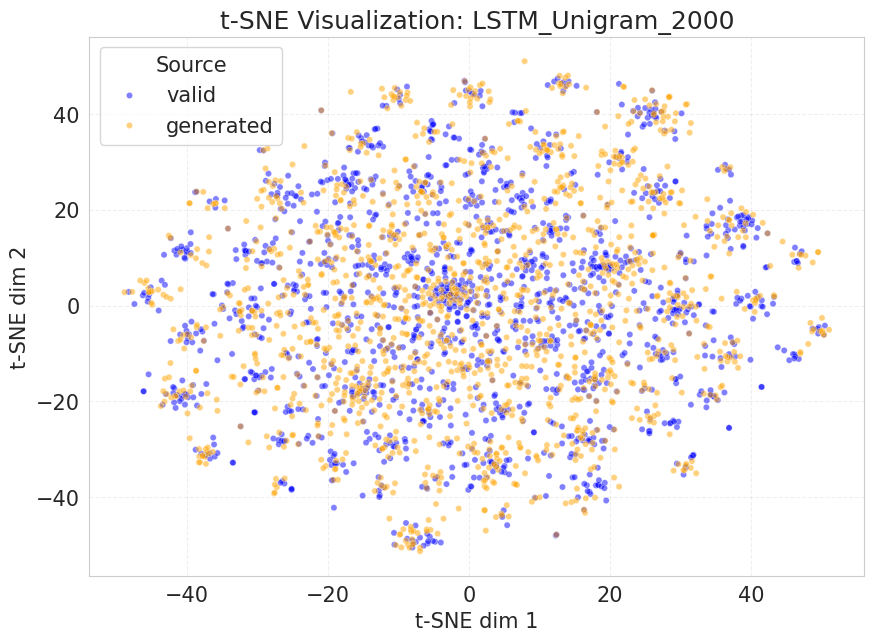

In [22]:
tsne_artifacts = {}

for name, artifact in lsa_artifacts.items():
    X_2d, labels = visualize_model_tsne(name, artifact, TSNE_CFG)
    tsne_artifacts[name] = {'X_2d': X_2d, 'labels': labels}

## Задание 8. ruGPT perplexity (3.5 балла)

Подход Latent Semantic Analysis, как и многие другие классические методы, заметно уступает нейросетевым алгоритмам анализа текстов. Вернемся к оцениванию качества генерации с помощью perplexity, для этого возьмем большую и хорошо обученную языковую модель, которая училась на огромном корпусе русских текстов. Считается, что большие языковые модели хорошо выучивают естественный язык, потому с их помощью мы сможем оценивать качество наших маленьких моделей для генерации анекдотов. Для этого мы воспользуемся сервисом [HuggingFace](https://huggingface.co/), который содержит огромное число обученных моделей для самых разных задач. Изучите и реализуйте, [подсчет perplexity](https://huggingface.co/docs/transformers/perplexity), с использованием обученной языковой модели. В качестве модели возьмите [ruGPT3-small](https://huggingface.co/sberbank-ai/rugpt3small_based_on_gpt2). Сгенерируйте синтетические выборки тремя моделями, обученными выше (можете взять выборки из задания 6), и сравните их по perplexity.

In [23]:
from transformers import AutoTokenizer, AutoModelForCausalLM

RUGPT_MODEL_NAME = 'sberbank-ai/rugpt3small_based_on_gpt2'
RUGPT_STRIDE = 512
RUGPT_MAX_SAMPLES = 1000

In [24]:
def normalize_texts_for_eval(texts):
    """Базовая очистка текстов перед оценкой."""
    return [t.strip() for t in texts if len(t.strip()) > 0]

In [25]:
def load_rugpt(model_name, device):
    """Загрузка модели и токенизатора из HuggingFace."""
    print(f"Loading {model_name}...")
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
    model.eval()
    return tokenizer, model

In [26]:
def compute_perplexity(texts, tokenizer, model, device, stride=RUGPT_STRIDE):
    """Вычисление perplexity по методике скользящего окна (HuggingFace)."""
    encodings = tokenizer("\n\n".join(texts), return_tensors="pt")
    max_length = model.config.n_positions
    seq_len = encodings.input_ids.size(1)

    nlls = []
    prev_end_loc = 0
    for begin_loc in tqdm(range(0, seq_len, stride), desc="Computing PPL"):
        end_loc = min(begin_loc + max_length, seq_len)
        trg_len = end_loc - prev_end_loc
        input_ids = encodings.input_ids[:, begin_loc:end_loc].to(device)
        target_ids = input_ids.clone()
        target_ids[:, :-trg_len] = -100

        with torch.no_grad():
            outputs = model(input_ids, labels=target_ids)
            neg_log_likelihood = outputs.loss * trg_len

        nlls.append(neg_log_likelihood)

        prev_end_loc = end_loc
        if end_loc == seq_len:
            break

    ppl = torch.exp(torch.stack(nlls).sum() / end_loc)
    return ppl.item()

In [27]:
tokenizer_rugpt, model_rugpt = load_rugpt(RUGPT_MODEL_NAME, device)

rugpt_results = []
rugpt_eval_artifacts = {}

# Используем корпуса, сгенерированные в Задании 6 (из lsa_artifacts)
for name, artifact in lsa_artifacts.items():
    print(f"\nEvaluating {name} with ruGPT...")
    
    gen_texts = generate_texts(models_to_evaluate[[m[0] for m in models_to_evaluate].index(name)][1], 
                               n_samples=RUGPT_MAX_SAMPLES)
    
    clean_texts = normalize_texts_for_eval(gen_texts)
    ppl = compute_perplexity(clean_texts, tokenizer_rugpt, model_rugpt, device)
    
    rugpt_results.append({'Model': name, 'ruGPT_Perplexity': ppl})
    rugpt_eval_artifacts[name] = {'texts': clean_texts, 'ppl': ppl}

df_rugpt = pd.DataFrame(rugpt_results).sort_values('ruGPT_Perplexity')
df_rugpt

Loading sberbank-ai/rugpt3small_based_on_gpt2...


config.json:   0%|          | 0.00/720 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...


Evaluating LSTM_BPE_5000 with ruGPT...


Computing PPL:  93%|█████████▎| 55/59 [00:02<00:00, 18.68it/s]



Evaluating LSTM_Unigram_2000 with ruGPT...


Computing PPL:  94%|█████████▎| 58/62 [00:03<00:00, 18.76it/s]


,Model,ruGPT_Perplexity
0,LSTM_BPE_2000,504.737793
1,LSTM_BPE_5000,522.864685
2,LSTM_Unigram_2000,617.694702


## Бонус (0.1 балл)

Покажите лучший анекдот, который удалось сгенерировать вашей модели. Если проверяющий найдет его смешным, то поставит 0.1 балла.